# Final Project - Viral Social Media Trends & Engagement Analysis Dataset
----
#### April 28, 2025
#### Name: Lauryn Chandler 
#### Student Id: 003127042
#### Source: Viral Social Media Trends & Engagement Analysis Dataset

In [221]:
# Import the Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [145]:
# Load the dataset
df = pd.read_csv('Viral_Social_Media_Trends.csv')
df

,Post_ID,Platform,Hashtag,Content_Type,Region,Views,Likes,Shares,Comments,Engagement_Level
0,Post_1,TikTok,#Challenge,Video,UK,4163464,339431,53135,19346,High
1,Post_2,Instagram,#Education,Shorts,India,4155940,215240,65860,27239,Medium
2,Post_3,Twitter,#Challenge,Video,Brazil,3666211,327143,39423,36223,Medium
3,Post_4,YouTube,#Education,Shorts,Australia,917951,127125,11687,36806,Low
4,Post_5,TikTok,#Dance,Post,Brazil,64866,171361,69581,6376,Medium
...,...,...,...,...,...,...,...,...,...,...
4995,Post_4996,YouTube,#Education,Video,Japan,4258236,381509,59209,4674,High
4996,Post_4997,Instagram,#Education,Video,UK,4841525,166266,54841,4832,Medium
4997,Post_4998,YouTube,#Fashion,Shorts,USA,2004080,32401,75229,33875,Low
4998,Post_4999,Instagram,#Gaming,Shorts,Canada,2221665,46996,12954,42832,Low


In [11]:
#shape of dataset, rows by columns
df.shape

(5000, 10)

In [13]:
#display general info of the dataset as a summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Post_ID           5000 non-null   object
 1   Platform          5000 non-null   object
 2   Hashtag           5000 non-null   object
 3   Content_Type      5000 non-null   object
 4   Region            5000 non-null   object
 5   Views             5000 non-null   int64 
 6   Likes             5000 non-null   int64 
 7   Shares            5000 non-null   int64 
 8   Comments          5000 non-null   int64 
 9   Engagement_Level  5000 non-null   object
dtypes: int64(4), object(6)
memory usage: 390.8+ KB


In [15]:
#display first 5 rows
df.head()

,Post_ID,Platform,Hashtag,Content_Type,Region,Views,Likes,Shares,Comments,Engagement_Level
0,Post_1,TikTok,#Challenge,Video,UK,4163464,339431,53135,19346,High
1,Post_2,Instagram,#Education,Shorts,India,4155940,215240,65860,27239,Medium
2,Post_3,Twitter,#Challenge,Video,Brazil,3666211,327143,39423,36223,Medium
3,Post_4,YouTube,#Education,Shorts,Australia,917951,127125,11687,36806,Low
4,Post_5,TikTok,#Dance,Post,Brazil,64866,171361,69581,6376,Medium


In [17]:
#identify variable type, only a few integer values, mostly strings and floats
df.dtypes

Post_ID             object
Platform            object
Hashtag             object
Content_Type        object
Region              object
Views                int64
Likes                int64
Shares               int64
Comments             int64
Engagement_Level    object
dtype: object

In [19]:
#identify column types
df.columns

Index(['Post_ID', 'Platform', 'Hashtag', 'Content_Type', 'Region', 'Views',
       'Likes', 'Shares', 'Comments', 'Engagement_Level'],
      dtype='object')

In [23]:
# Checking for null values, no missing values
df.isnull().sum()

Post_ID             0
Platform            0
Hashtag             0
Content_Type        0
Region              0
Views               0
Likes               0
Shares              0
Comments            0
Engagement_Level    0
dtype: int64

In [27]:
# Shows sum of duplicates, no duplicates
df.duplicated().sum() 

0

In [249]:
#create a copy of the data for data cleaning
df_new=df.copy()
df_new

,Post_ID,Platform,Hashtag,Content_Type,Region,Views,Likes,Shares,Comments,Engagement_Level
0,Post_1,TikTok,#Challenge,Video,UK,4163464,339431,53135,19346,High
1,Post_2,Instagram,#Education,Shorts,India,4155940,215240,65860,27239,Medium
2,Post_3,Twitter,#Challenge,Video,Brazil,3666211,327143,39423,36223,Medium
3,Post_4,YouTube,#Education,Shorts,Australia,917951,127125,11687,36806,Low
4,Post_5,TikTok,#Dance,Post,Brazil,64866,171361,69581,6376,Medium
...,...,...,...,...,...,...,...,...,...,...
4995,Post_4996,YouTube,#Education,Video,Japan,4258236,381509,59209,4674,High
4996,Post_4997,Instagram,#Education,Video,UK,4841525,166266,54841,4832,Medium
4997,Post_4998,YouTube,#Fashion,Shorts,USA,2004080,32401,75229,33875,Low
4998,Post_4999,Instagram,#Gaming,Shorts,Canada,2221665,46996,12954,42832,Low


In [251]:
#convert all text to lowercase, possibly case insensitive, spaces, etc)
df_new['Platform'] = df_new['Platform'].str.lower().str.strip()
df_new['Content_Type'] = df_new['Content_Type'].str.lower().str.strip()
df_new

,Post_ID,Platform,Hashtag,Content_Type,Region,Views,Likes,Shares,Comments,Engagement_Level
0,Post_1,tiktok,#Challenge,video,UK,4163464,339431,53135,19346,High
1,Post_2,instagram,#Education,shorts,India,4155940,215240,65860,27239,Medium
2,Post_3,twitter,#Challenge,video,Brazil,3666211,327143,39423,36223,Medium
3,Post_4,youtube,#Education,shorts,Australia,917951,127125,11687,36806,Low
4,Post_5,tiktok,#Dance,post,Brazil,64866,171361,69581,6376,Medium
...,...,...,...,...,...,...,...,...,...,...
4995,Post_4996,youtube,#Education,video,Japan,4258236,381509,59209,4674,High
4996,Post_4997,instagram,#Education,video,UK,4841525,166266,54841,4832,Medium
4997,Post_4998,youtube,#Fashion,shorts,USA,2004080,32401,75229,33875,Low
4998,Post_4999,instagram,#Gaming,shorts,Canada,2221665,46996,12954,42832,Low


In [253]:
#check to see options for "Content Type" category. 
df_new['Content_Type'].unique()

array(['video', 'shorts', 'post', 'tweet', 'live stream', 'reel'],
      dtype=object)

In [255]:
#Focusing on just video content, so removing rows with non-video content types, anything with tweet or post. 
df_new = df_new[~df_new['Content_Type'].isin(['tweet', 'post', 'live stream'])]
df_new

,Post_ID,Platform,Hashtag,Content_Type,Region,Views,Likes,Shares,Comments,Engagement_Level
0,Post_1,tiktok,#Challenge,video,UK,4163464,339431,53135,19346,High
1,Post_2,instagram,#Education,shorts,India,4155940,215240,65860,27239,Medium
2,Post_3,twitter,#Challenge,video,Brazil,3666211,327143,39423,36223,Medium
3,Post_4,youtube,#Education,shorts,Australia,917951,127125,11687,36806,Low
5,Post_6,instagram,#Challenge,shorts,Australia,1323566,136282,86979,47129,Low
...,...,...,...,...,...,...,...,...,...,...
4995,Post_4996,youtube,#Education,video,Japan,4258236,381509,59209,4674,High
4996,Post_4997,instagram,#Education,video,UK,4841525,166266,54841,4832,Medium
4997,Post_4998,youtube,#Fashion,shorts,USA,2004080,32401,75229,33875,Low
4998,Post_4999,instagram,#Gaming,shorts,Canada,2221665,46996,12954,42832,Low


In [257]:
#When looking to focus on videos, we also have four different social media platforms, each with its respective name for video content. 
#In some entries, columns with Instagram have shorts as the content type, when they are called Reels.
#Therefore, I cleaned the data so that if the Platform is Instagram and the content type is Shorts, it is changed to Reel instead.  
df_new.loc[(df['Platform'] == 'instagram') & (df['Content_Type'] == 'shorts'), 'Content_Type'] = 'Reel'
df_new

,Post_ID,Platform,Hashtag,Content_Type,Region,Views,Likes,Shares,Comments,Engagement_Level
0,Post_1,tiktok,#Challenge,video,UK,4163464,339431,53135,19346,High
1,Post_2,instagram,#Education,shorts,India,4155940,215240,65860,27239,Medium
2,Post_3,twitter,#Challenge,video,Brazil,3666211,327143,39423,36223,Medium
3,Post_4,youtube,#Education,shorts,Australia,917951,127125,11687,36806,Low
5,Post_6,instagram,#Challenge,shorts,Australia,1323566,136282,86979,47129,Low
...,...,...,...,...,...,...,...,...,...,...
4995,Post_4996,youtube,#Education,video,Japan,4258236,381509,59209,4674,High
4996,Post_4997,instagram,#Education,video,UK,4841525,166266,54841,4832,Medium
4997,Post_4998,youtube,#Fashion,shorts,USA,2004080,32401,75229,33875,Low
4998,Post_4999,instagram,#Gaming,shorts,Canada,2221665,46996,12954,42832,Low


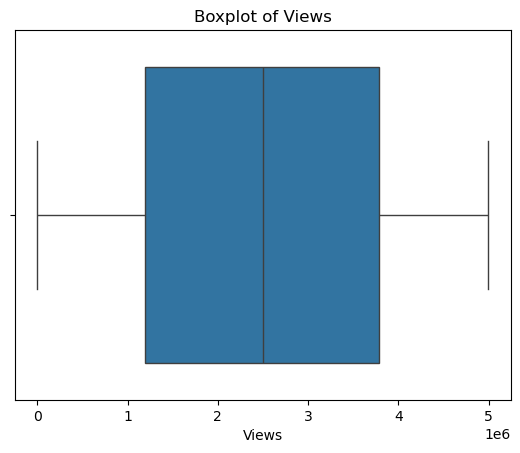

In [259]:
#use a boxplot to check for outliers in Views category
sns.boxplot(x=df_new['Views'])
plt.title('Boxplot of Views')
plt.show()

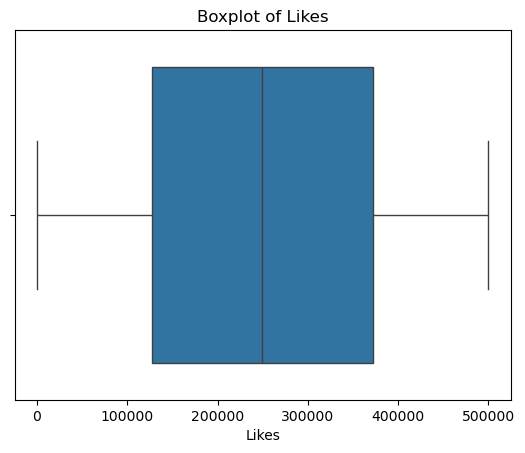

In [261]:
#use a boxplot to check for outliers in the Likes category
sns.boxplot(x=df_new['Likes'])
plt.title('Boxplot of Likes')
plt.show()

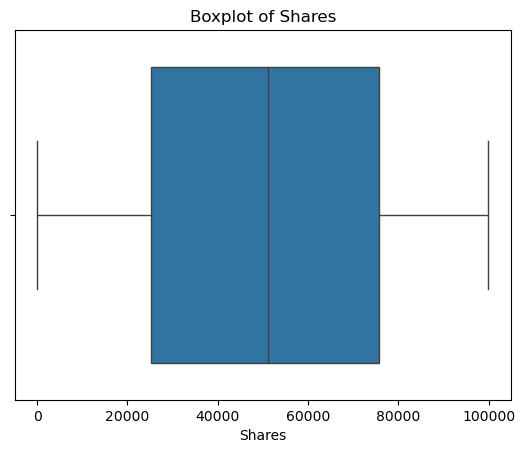

In [263]:
#use a boxplot to check for outliers in the Shares category
sns.boxplot(x=df_new['Shares'])
plt.title('Boxplot of Shares')
plt.show()

In [265]:
#Because I am looking at engagement across video length, I decided to make an engagement rate category open potential for deeper analysis
# new data frame, since cleaned
df_new = df_new.copy()  # To avoid slice error I received 
# Calculate Engagement Rate
df_new['Engagement_Rate'] = (df_new['Likes'] + df_new['Shares'] + df_new['Comments']) / df_new['Views']
# Convert to percentage
df_new['Engagement_Rate'] = df_new['Engagement_Rate'] * 100

In [267]:
df_new

,Post_ID,Platform,Hashtag,Content_Type,Region,Views,Likes,Shares,Comments,Engagement_Level,Engagement_Rate
0,Post_1,tiktok,#Challenge,video,UK,4163464,339431,53135,19346,High,9.893493
1,Post_2,instagram,#Education,shorts,India,4155940,215240,65860,27239,Medium,7.419236
2,Post_3,twitter,#Challenge,video,Brazil,3666211,327143,39423,36223,Medium,10.986520
3,Post_4,youtube,#Education,shorts,Australia,917951,127125,11687,36806,Low,19.131522
5,Post_6,instagram,#Challenge,shorts,Australia,1323566,136282,86979,47129,Low,20.428902
...,...,...,...,...,...,...,...,...,...,...,...
4995,Post_4996,youtube,#Education,video,Japan,4258236,381509,59209,4674,High,10.459542
4996,Post_4997,instagram,#Education,video,UK,4841525,166266,54841,4832,Medium,4.666691
4997,Post_4998,youtube,#Fashion,shorts,USA,2004080,32401,75229,33875,Low,7.060846
4998,Post_4999,instagram,#Gaming,shorts,Canada,2221665,46996,12954,42832,Low,4.626350


In [269]:
# Count unique values in Hashtags, Platforms, Content Types
unique_hashtags = df_new['Hashtag'].nunique()
unique_platforms = df_new['Platform'].nunique()
unique_content_types = df_new['Content_Type'].nunique()

print(f"Unique Hashtags: {unique_hashtags}")
print(f"Unique Platforms: {unique_platforms}")
print(f"Unique Content Types: {unique_content_types}")

Unique Hashtags: 10
Unique Platforms: 4
Unique Content Types: 3


### DATA VISUALIZATION AND INTERPRETATION

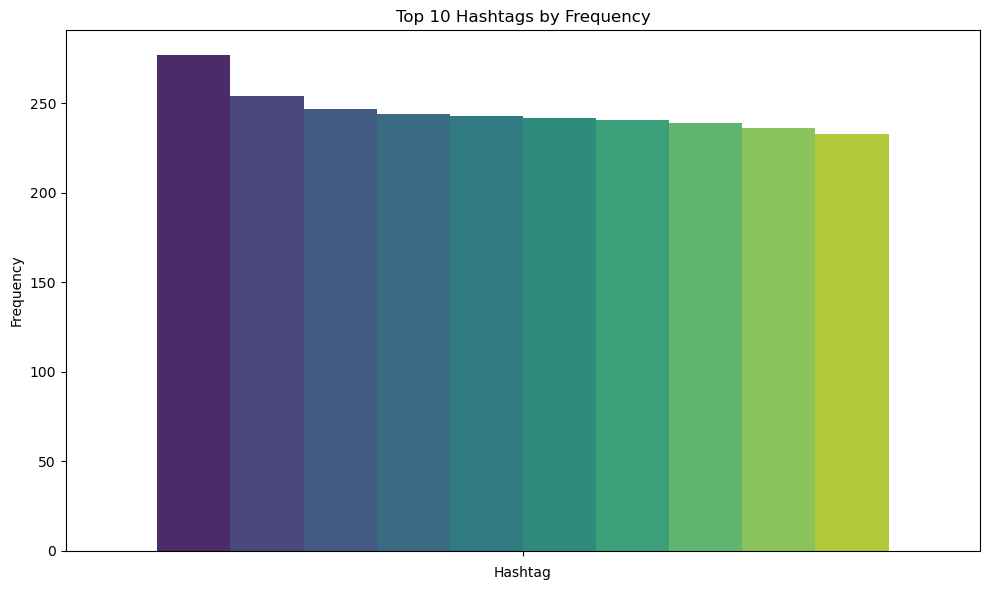

In [336]:
# Count the frequency of each hashtag
hashtag_counts = df_new['Hashtag'].value_counts().head(10)

# Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(hue=hashtag_counts.index, y=hashtag_counts.values, palette='viridis',legend=False)

plt.title('Top 10 Hashtags by Frequency')
plt.xlabel('Hashtag')
plt.ylabel('Frequency')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('top10hashtags.jpg')
plt.show()

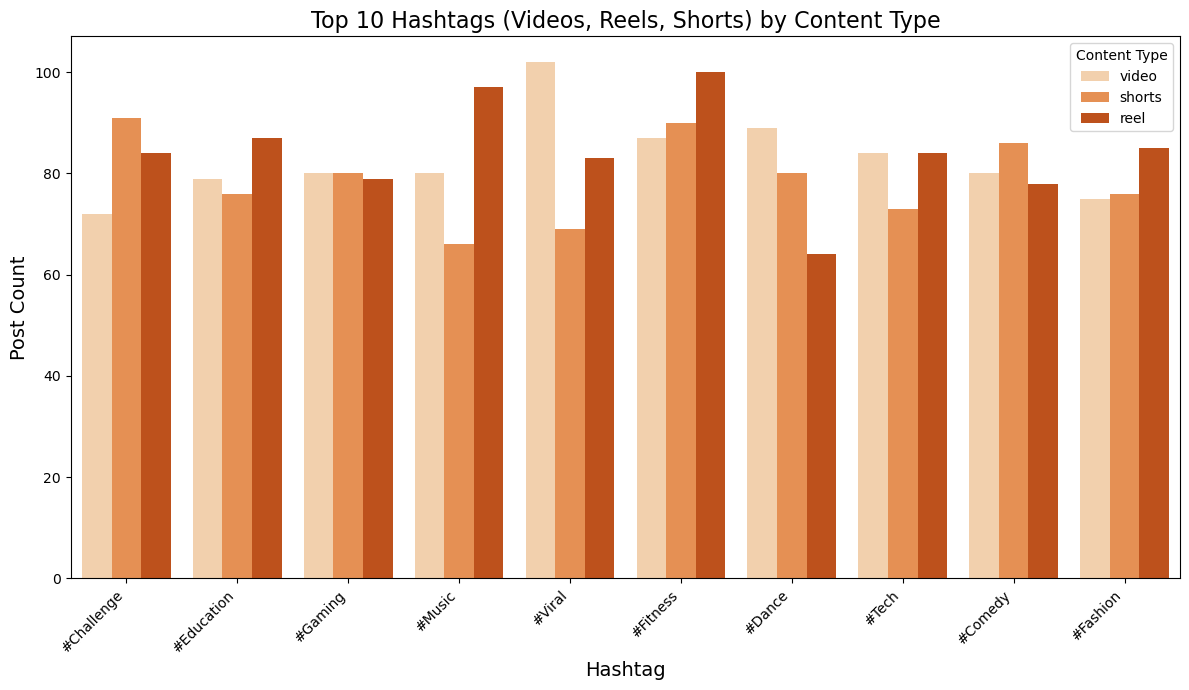

In [399]:
#Find the top 10 hashtags from filtered data
top_10_hashtags = df_new['Hashtag'].value_counts().head(10).index

#Filter again to only keep posts with those top hashtags
top_hashtag_df = df_new[df_new['Hashtag'].isin(top_10_hashtags)]

#Plot the grouped bar plot
plt.figure(figsize=(12, 7))
sns.countplot(data=top_hashtag_df, x='Hashtag', hue='Content_Type', palette='Oranges')
plt.title('Top 10 Hashtags (Videos, Reels, Shorts) by Content Type', fontsize=16)
plt.xlabel('Hashtag', fontsize=14)
plt.ylabel('Post Count', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Content Type')
plt.tight_layout()
plt.savefig('top10bycontent.jpg')
plt.show()

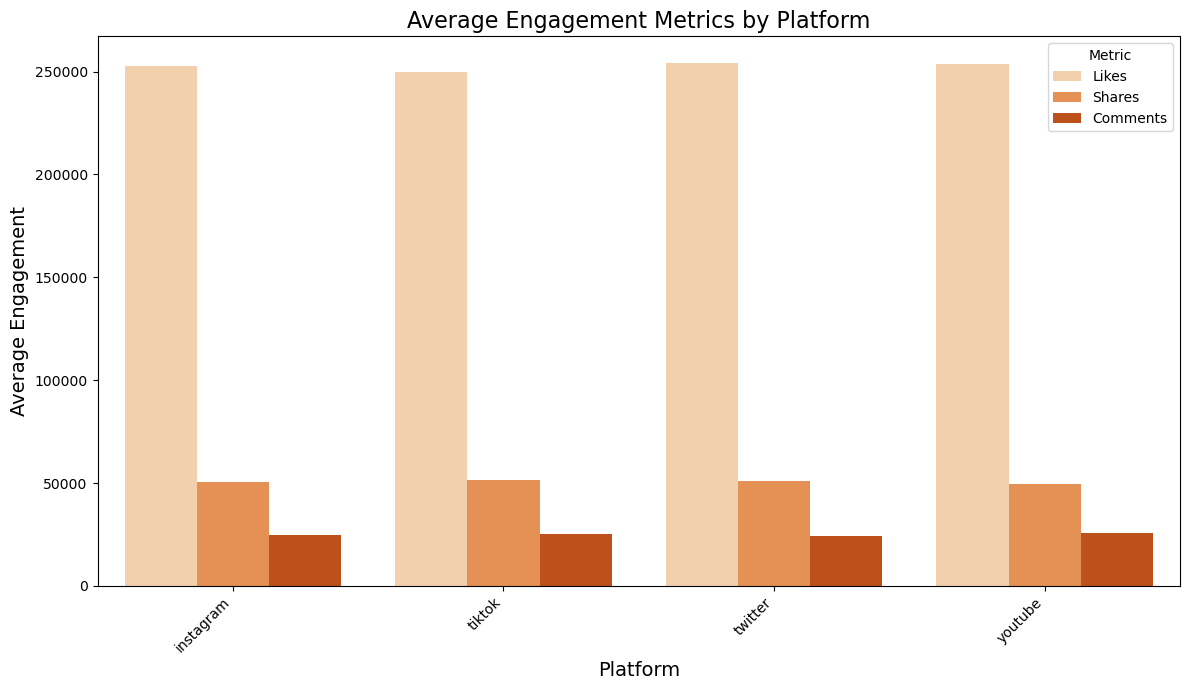

In [344]:
#Group by Platform and calculate the mean (or sum) of Likes, Shares, Comments
platform_engagement = df_new.groupby('Platform')[['Likes', 'Shares', 'Comments']].mean().reset_index()

#Melt the dataframe
platform_engagement_melted = platform_engagement.melt(id_vars='Platform', 
                                                       value_vars=['Likes', 'Shares', 'Comments'],
                                                       var_name='Metric', 
                                                       value_name='Average')

#Barplot
plt.figure(figsize=(12, 7))
sns.barplot(data=platform_engagement_melted, x='Platform', y='Average', hue='Metric', palette='Oranges')
plt.title('Average Engagement Metrics by Platform', fontsize=16)
plt.xlabel('Platform', fontsize=14)
plt.ylabel('Average Engagement', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.tight_layout()
plt.savefig('avgengbyplatform.jpg')
plt.show()

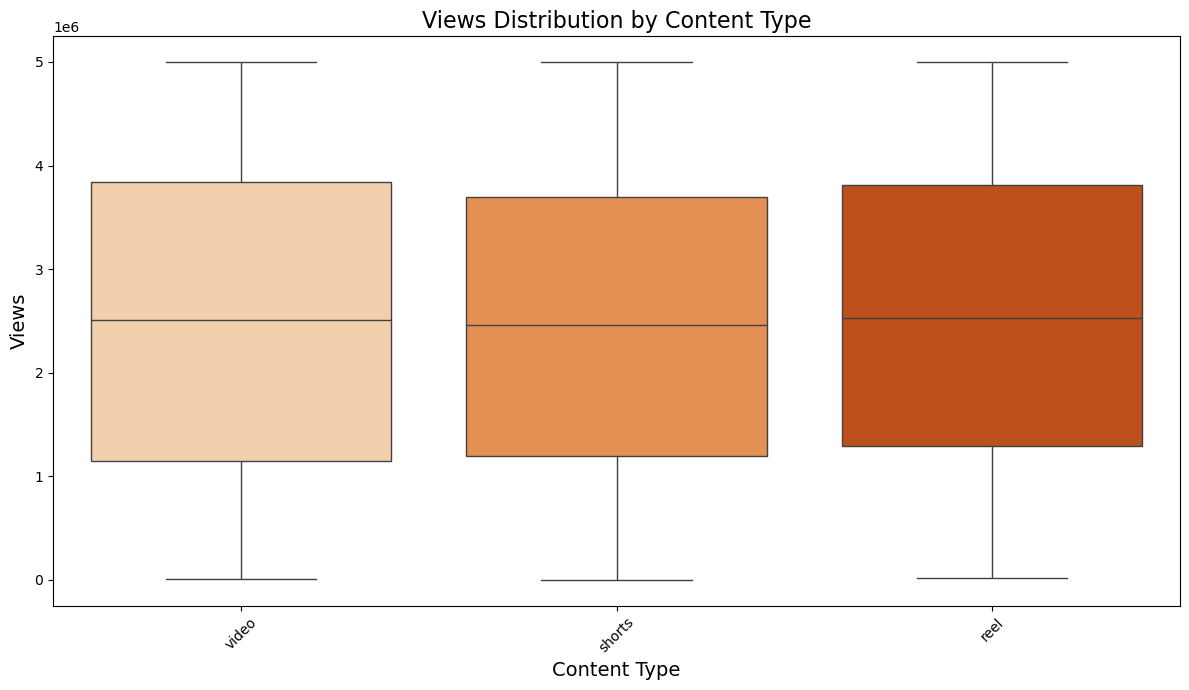

In [346]:
#Plot the boxplot for view distribution by content type
plt.figure(figsize=(12, 7))
sns.boxplot(data=df_new, x='Content_Type', y='Views', hue='Content_Type', palette='Oranges', legend=False)
plt.title('Views Distribution by Content Type', fontsize=16)
plt.xlabel('Content Type', fontsize=14)
plt.ylabel('Views', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('viewsbytype.jpg')
plt.show()

/var/folders/_x/tdh8tq8d13x56xn7yvh2m24r0000gn/T/ipykernel_7278/2936190386.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




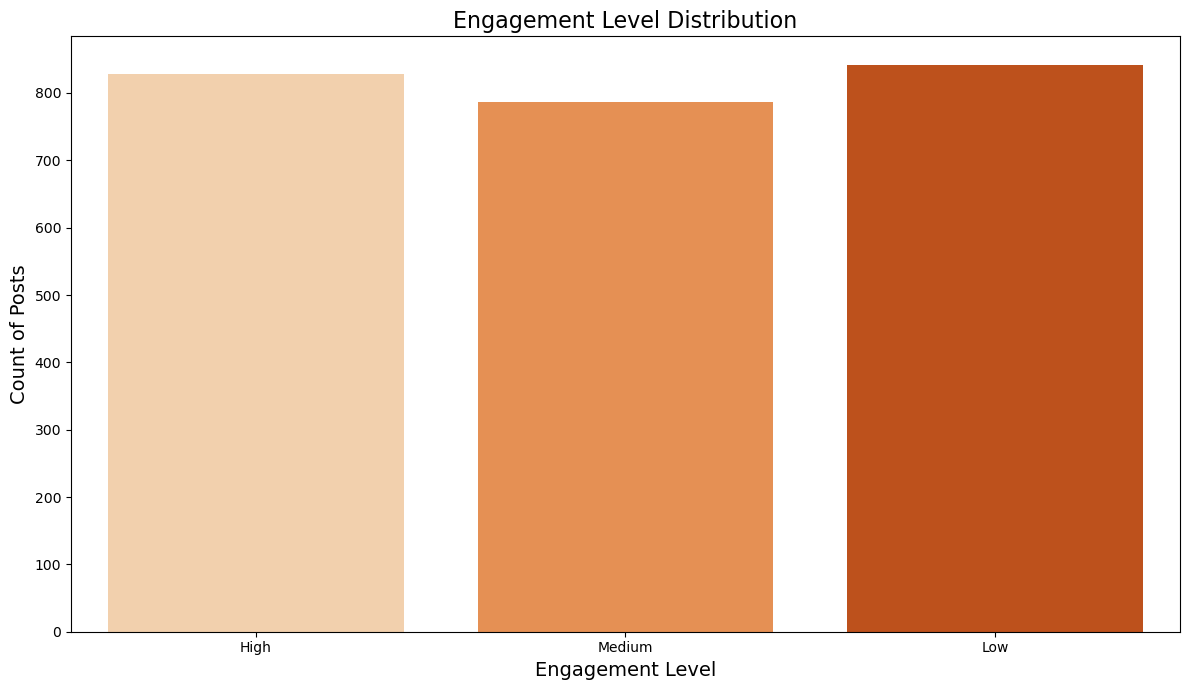

In [348]:
# Plot the count plot for engagement level distribution
plt.figure(figsize=(12, 7))
sns.countplot(data=df_new, x='Engagement_Level', palette='Oranges')
plt.title('Engagement Level Distribution', fontsize=16)
plt.xlabel('Engagement Level', fontsize=14)
plt.ylabel('Count of Posts', fontsize=14)
plt.tight_layout()
plt.savefig('top10bycontent.jpg')
plt.show()

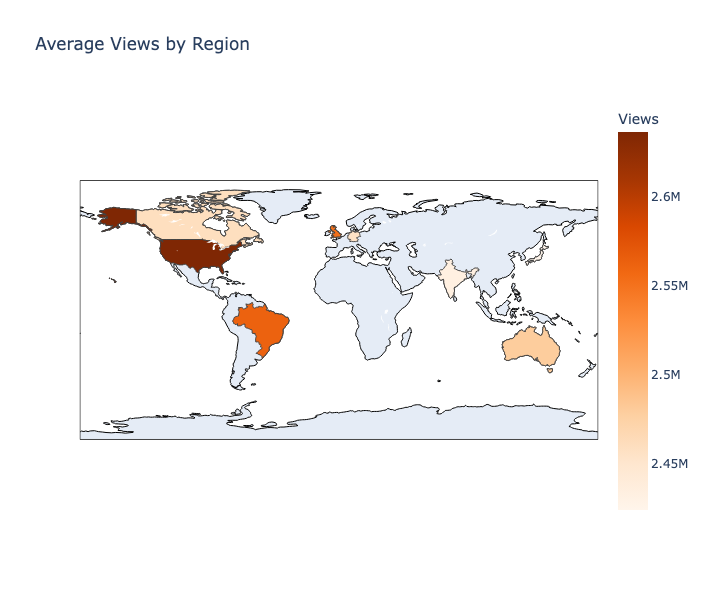

In [350]:
#Group by 'Region' and calculate the average views for each region
average_views_by_region = df_new.groupby('Region')['Views'].mean().reset_index()

#Plotly choropleth map
fig = px.choropleth(average_views_by_region,
                    locations="Region",  # Use the Region column for locations
                    locationmode="country names",  # Use country names for mapping
                    color="Views",  
                    hover_name="Region",  
                    color_continuous_scale="Oranges",  
                    title="Average Views by Region",  
                    height=600)  

fig.update_geos(showcoastlines=True, coastlinecolor="Black")
fig.write_html("viewsbyregion.html")
fig.show()


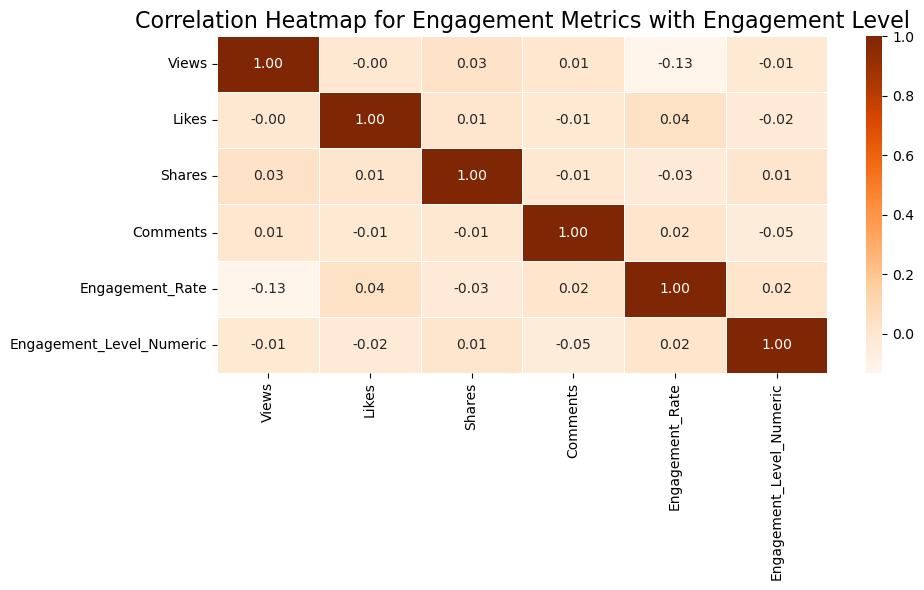

In [352]:
#Convert Engagement Level to numerical values
engagement_level_mapping = {'Low': 1, 'Medium': 2, 'High': 3}
df_new['Engagement_Level_Numeric'] = df_new['Engagement_Level'].map(engagement_level_mapping)

#Select the relevant engagement columns
engagement_columns = ['Views', 'Likes', 'Shares', 'Comments', 'Engagement_Rate', 'Engagement_Level_Numeric']

#Calculate the correlation matrix
correlation_matrix = df_new[engagement_columns].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='Oranges', fmt='.2f', cbar=True, linewidths=0.5)

plt.title('Correlation Heatmap for Engagement Metrics with Engagement Level', fontsize=16)
plt.tight_layout()
plt.savefig('heatmapengagement.jpg')
plt.show()

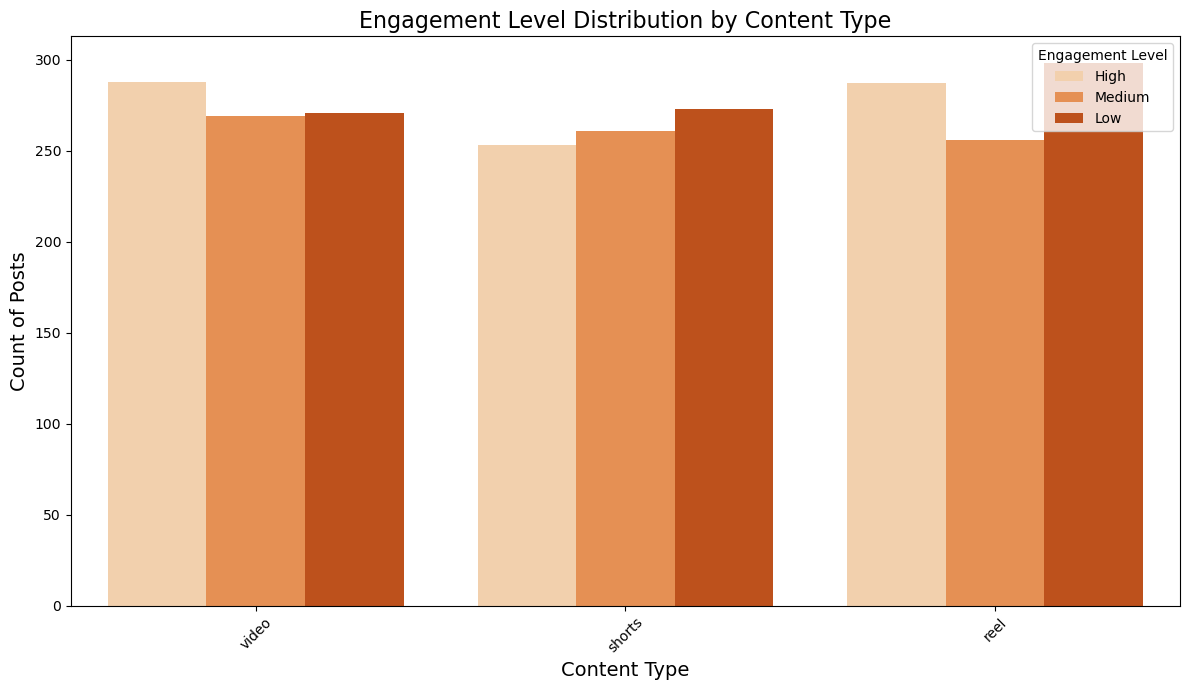

In [360]:
#Create the count plot for Engagement Level by Content Type
plt.figure(figsize=(12, 7))
sns.countplot(data=df_new, x='Content_Type', hue='Engagement_Level', palette='Oranges')

plt.title('Engagement Level Distribution by Content Type', fontsize=16)
plt.xlabel('Content Type', fontsize=14)
plt.ylabel('Count of Posts', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='Engagement Level', loc='upper right')
plt.tight_layout()
plt.savefig('engbycontentcount.jpg')
plt.show()

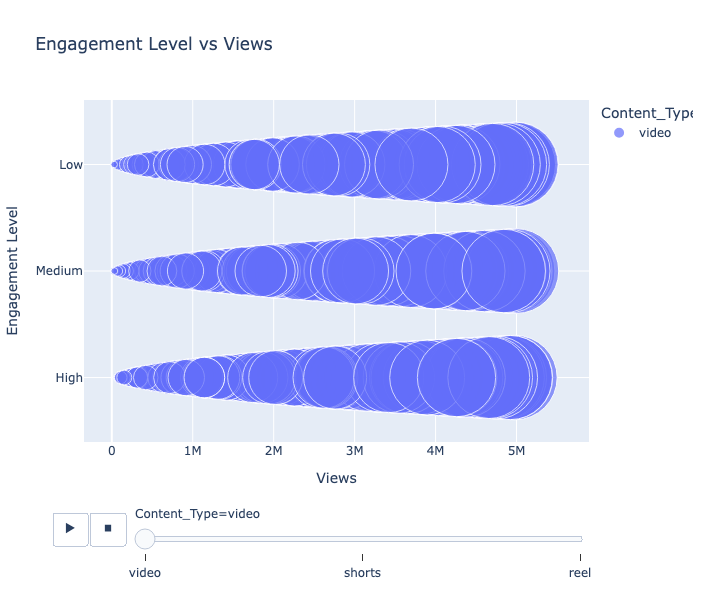

In [354]:
#Engageement levels by views scatterplot (animated)
fig = px.scatter(df_new, 
                 x="Views", 
                 y="Engagement_Level", 
                 color="Content_Type",  
                 animation_frame="Content_Type",  
                 title="Engagement Level vs Views",
                 size="Views",  
                 hover_name="Content_Type", 
                 color_continuous_scale="Oranges", 
                 size_max=60,  
                 labels={"Views": "Views", "Engagement_Level": "Engagement Level"})  

fig.update_layout(showlegend=True, height=600)
fig.show()

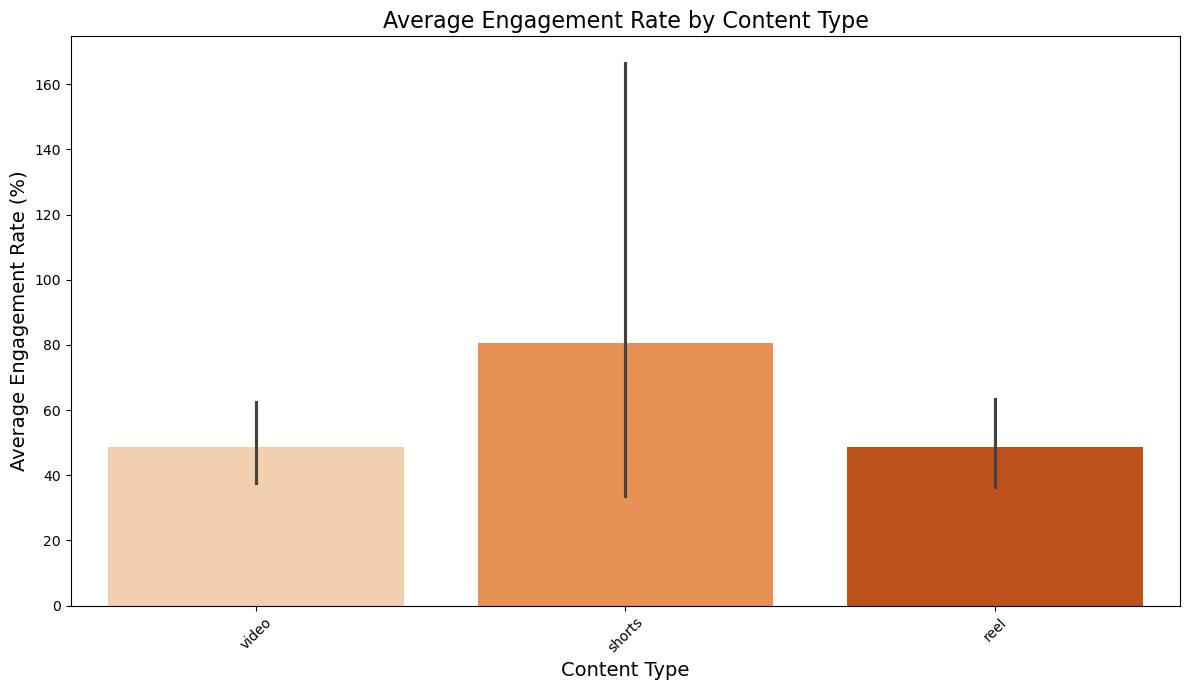

In [358]:
#barplot fot engagement rate by content type
plt.figure(figsize=(12, 7))

sns.barplot(x='Content_Type', y='Engagement_Rate', data=df_new, palette='Oranges', hue='Content_Type', legend=False)

plt.title('Average Engagement Rate by Content Type', fontsize=16)
plt.xlabel('Content Type', fontsize=14)
plt.ylabel('Average Engagement Rate (%)', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('avgengbytype.jpg')
plt.show()


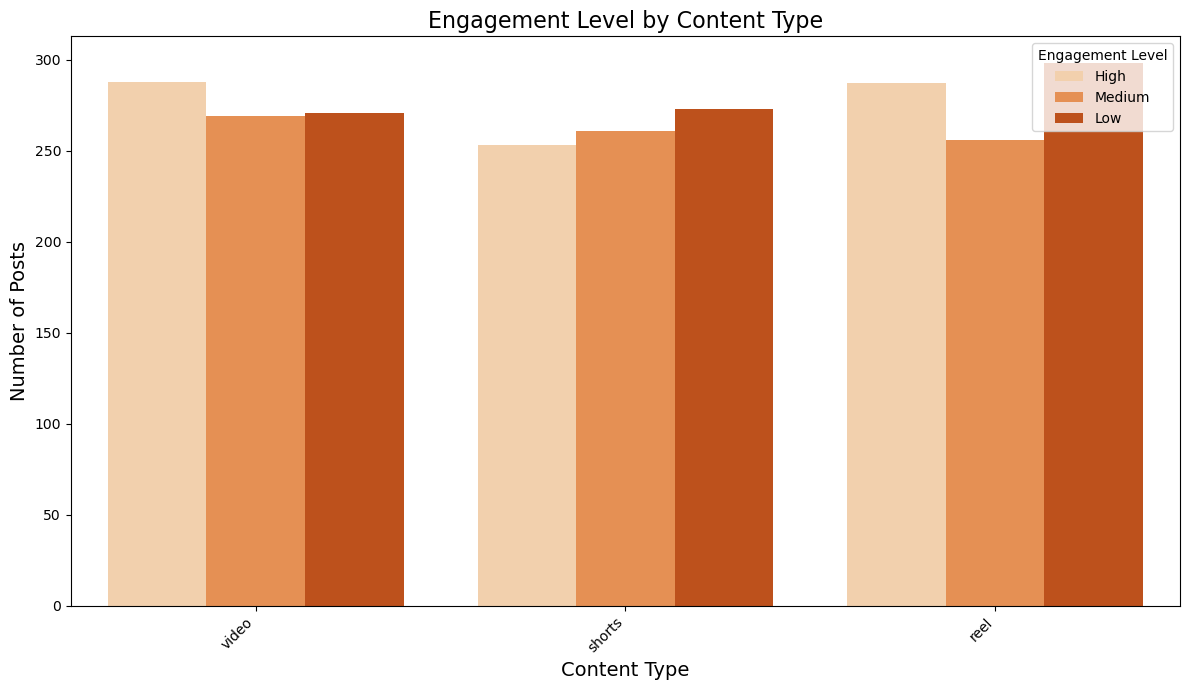

In [370]:
plt.figure(figsize=(12, 7))
sns.countplot(data=df_new, x='Content_Type', hue='Engagement_Level', palette='Oranges')

plt.title('Engagement Level by Content Type', fontsize=16)
plt.xlabel('Content Type', fontsize=14)
plt.ylabel('Number of Posts', fontsize=14)

# Rotate the x-axis labels for better readability if necessary
plt.xticks(rotation=45, ha='right')

# Add a legend
plt.legend(title='Engagement Level')

# Adjust the layout
plt.tight_layout()
plt.savefig('levelbytype.jpg')
# Show the plot
plt.show()

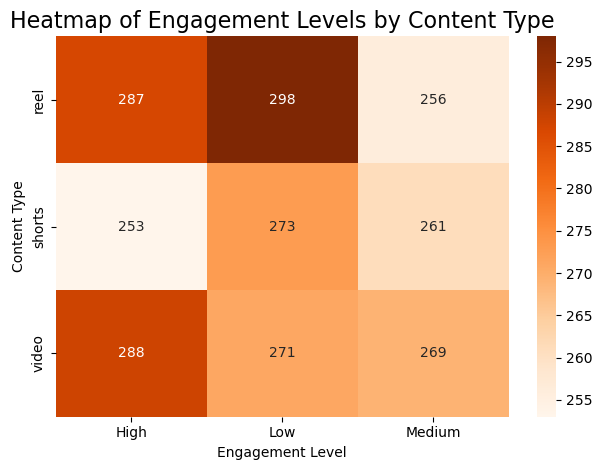

In [397]:
# Pivot for heatmap
pivot_df = df_new.pivot_table(index='Content_Type', columns='Engagement_Level', aggfunc='size', fill_value=0)

# Plot heatmap
sns.heatmap(pivot_df, annot=True, fmt='d', cmap='Oranges')
plt.title('Heatmap of Engagement Levels by Content Type', fontsize=16)
plt.xlabel('Engagement Level')
plt.ylabel('Content Type')
plt.tight_layout()
plt.savefig('engagementheatmap.jpg')
plt.show()
